In [1]:
# PHASE 3: Classification — Random Forest
# ============================================================================
# This notebook trains a Random Forest classifier on the feature matrix
# from Phase 2 to predict the structural condition (6 classes: perfect,
# imperfect_1 through imperfect_5).
#
# Evaluation approach: Leave-One-Out Cross-Validation (LOOCV)
#   - Train on 18 samples, test on 1, repeat 19 times
#   - This maximises training data at each fold, critical with only 19 samples
#   - Produces 19 predictions for computing confusion matrix and accuracy
#
# After cross-validation, the model is retrained on all 19 samples and
# used to predict the held-out test case (Imperfect_no_4, ground truth known).
# ============================================================================

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("All imports loaded successfully.")

All imports loaded successfully.


In [2]:
# Load the feature matrix from Phase 2
# ============================================================================

os.chdir(os.path.join(os.getcwd(), ".."))
print(f"Working directory: {os.getcwd()}")

df_features = pd.read_csv("data/feature_matrix.csv")

# Separate test case from training data
test_folder = "Imperfect_no_4_1_train_middle_track_2000N"
df_train = df_features[df_features["folder_name"] != test_folder].copy()
df_test = df_features[df_features["folder_name"] == test_folder].copy()

# Identify feature columns (everything except metadata)
meta_cols = ["folder_name", "label"]
feature_cols = [c for c in df_features.columns if c not in meta_cols]

# Encode labels
le = LabelEncoder()
le.fit(sorted(df_train["label"].unique()))

X_train_raw = df_train[feature_cols].values
y_train = le.transform(df_train["label"].values)
X_test_raw = df_test[feature_cols].values
y_test = le.transform(df_test["label"].values)

print(f"Training set: {X_train_raw.shape[0]} samples, {X_train_raw.shape[1]} features")
print(f"Test set: {X_test_raw.shape[0]} sample")
print(f"\nLabel encoding:")
for i, label in enumerate(le.classes_):
    count = np.sum(y_train == i)
    print(f"  {i} -> {label} ({count} training samples)")

Working directory: c:\Users\Vishal Prabu\Desktop\genai-projects\structural-health-monitoring
Training set: 19 samples, 336 features
Test set: 1 sample

Label encoding:
  0 -> imperfect_1 (3 training samples)
  1 -> imperfect_2 (3 training samples)
  2 -> imperfect_3 (3 training samples)
  3 -> imperfect_4 (3 training samples)
  4 -> imperfect_5 (3 training samples)
  5 -> perfect (4 training samples)


In [3]:
# ============================================================================
# Leave-One-Out Cross-Validation with Random Forest
# ============================================================================
# LOOCV trains on 18 samples and tests on 1, repeated 19 times.
# At each fold:
#   1. StandardScaler is fitted on the 18 training samples only
#   2. Both training and test samples are transformed using that scaler
#   3. Random Forest is trained and predicts the held-out sample
#
# This ensures no data leakage — the held-out sample never influences
# the scaling or the model training.
#
# Random Forest hyperparameters are kept at reasonable defaults for now:
#   n_estimators=200  (number of trees — more is generally better)
#   random_state=42   (reproducibility)
#   class_weight="balanced" (compensates for unequal class sizes:
#                            perfect has 4 samples, imperfects have 3 each)
# ============================================================================

loo = LeaveOneOut()
y_true_all = []
y_pred_all = []
folder_names_all = []

for train_idx, test_idx in loo.split(X_train_raw):
    # Split
    X_fold_train = X_train_raw[train_idx]
    X_fold_test = X_train_raw[test_idx]
    y_fold_train = y_train[train_idx]
    y_fold_test = y_train[test_idx]
    
    # Scale (fitted on this fold's training data only)
    scaler = StandardScaler()
    X_fold_train_scaled = scaler.fit_transform(X_fold_train)
    X_fold_test_scaled = scaler.transform(X_fold_test)
    
    # Train
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
    rf.fit(X_fold_train_scaled, y_fold_train)
    
    # Predict
    pred = rf.predict(X_fold_test_scaled)
    
    y_true_all.append(y_fold_test[0])
    y_pred_all.append(pred[0])
    folder_names_all.append(df_train.iloc[test_idx[0]]["folder_name"])

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Results
accuracy = accuracy_score(y_true_all, y_pred_all)
print(f"LOOCV Accuracy: {accuracy:.2%} ({np.sum(y_true_all == y_pred_all)}/{len(y_true_all)} correct)")
print(f"\nPer-sample results:")
for folder, true, pred in zip(folder_names_all, y_true_all, y_pred_all):
    status = "OK" if true == pred else "WRONG"
    print(f"  [{status}] {folder}")
    if true != pred:
        print(f"         True: {le.classes_[true]}, Predicted: {le.classes_[pred]}")

LOOCV Accuracy: 78.95% (15/19 correct)

Per-sample results:
  [OK] Perfect_structure_1_train_extreme_track_2000N
  [OK] Perfect_structure_1_train_extreme_rack_5000N
  [OK] Perfect_structure_2_trains_opposite_direction_extreme_tracks_2000N
  [OK] Perfect_structure_1_train_middle_track_2000N
  [WRONG] Imperfect_no_1_1_train_extreme_track_2000N
         True: imperfect_1, Predicted: imperfect_2
  [OK] Imperfect_no_1_1_train_extreme_track_5000N
  [OK] Imperfect_no_1_2_trains_opposite_direction_extreme_track_2000N
  [OK] Imperfect_no_2_1_train_extreme_track_2000N
  [WRONG] imperfect_no_2_1_train_extreme_Track_5000N
         True: imperfect_2, Predicted: imperfect_1
  [OK] Imperfect_no_2_2_trains_opposite_direction_Extreme_tracks_2000N
  [WRONG] Imperfect_no_3_1_train_extreme_track_2000N
         True: imperfect_3, Predicted: imperfect_5
  [OK] imperfect_no_3_1_train_extreme_track_5000N
  [OK] Imperfect_no_3_2_trains_opposite_direction_extreme_tracks_2000N
  [OK] imperfect_no_4_1_train_extre

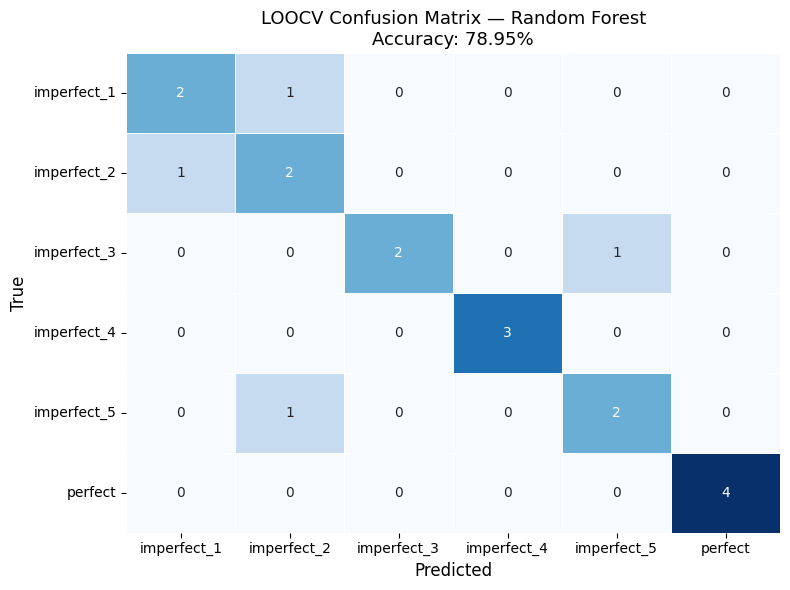


Classification Report:
              precision    recall  f1-score   support

 imperfect_1       0.67      0.67      0.67         3
 imperfect_2       0.50      0.67      0.57         3
 imperfect_3       1.00      0.67      0.80         3
 imperfect_4       1.00      1.00      1.00         3
 imperfect_5       0.67      0.67      0.67         3
     perfect       1.00      1.00      1.00         4

    accuracy                           0.79        19
   macro avg       0.81      0.78      0.78        19
weighted avg       0.82      0.79      0.80        19



In [4]:
# Confusion matrix from LOOCV results
cm = confusion_matrix(y_true_all, y_pred_all)
labels = le.classes_

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels,
            yticklabels=labels, ax=ax, cbar=False, linewidths=0.5)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"LOOCV Confusion Matrix — Random Forest\nAccuracy: {accuracy:.2%}", fontsize=13)
plt.tight_layout()
plt.savefig("results/06_confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=labels))

In [5]:
# Train on all 19 samples and predict the test case
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_raw)
X_test_scaled = scaler_final.transform(X_test_raw)

rf_final = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_final.fit(X_train_scaled, y_train)

test_pred = rf_final.predict(X_test_scaled)
test_pred_label = le.classes_[test_pred[0]]
test_true_label = le.classes_[y_test[0]]

print(f"Test case: {test_folder}")
print(f"  Predicted: {test_pred_label}")
print(f"  Actual:    {test_true_label}")
print(f"  Correct:   {test_pred_label == test_true_label}")

# Prediction probabilities per class
test_proba = rf_final.predict_proba(X_test_scaled)[0]
print(f"\nClass probabilities:")
for label, prob in zip(le.classes_, test_proba):
    bar = "█" * int(prob * 40)
    print(f"  {label:15s} {prob:.3f} {bar}")

Test case: Imperfect_no_4_1_train_middle_track_2000N
  Predicted: perfect
  Actual:    imperfect_4
  Correct:   False

Class probabilities:
  imperfect_1     0.045 █
  imperfect_2     0.205 ████████
  imperfect_3     0.000 
  imperfect_4     0.225 █████████
  imperfect_5     0.055 ██
  perfect         0.470 ██████████████████


In [6]:
# Instead of using default Random Forest settings, 108 combinations of
# four key hyperparameters are tested to find the best LOOCV accuracy.
#
#   n_estimators: number of trees in the forest. More trees = more stable
#                 predictions but slower training.
#   max_depth: maximum depth each tree can grow. Limiting depth prevents
#              overfitting by stopping trees from memorising training data.
#              None = unlimited.
#   min_samples_split: minimum samples required to split a node further.
#                      Higher values = more conservative, less overfitting.
#   max_features: fraction/method for selecting features at each split.
#                 Using a subset forces diversity among trees — each tree
#                 sees a different view of the 336 features.
#
# For each combination, the full LOOCV loop (19 folds) is run and
# accuracy is recorded. Total runs: 108 combos × 19 folds = 2,052.
# Grid search!
from itertools import product

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 3],
    "max_features": ["sqrt", "log2"],
}

# Generate all combinations
keys = list(param_grid.keys())
values = list(param_grid.values())
all_combos = [dict(zip(keys, combo)) for combo in product(*values)]
print(f"Total combinations to test: {len(all_combos)}")

loo = LeaveOneOut()
best_acc = 0
best_params = None
results = []

for i, params in enumerate(all_combos):
    y_preds = []
    y_trues = []
    
    for train_idx, test_idx in loo.split(X_train_raw):
        X_fold_train = X_train_raw[train_idx]
        X_fold_test = X_train_raw[test_idx]
        y_fold_train = y_train[train_idx]
        y_fold_test = y_train[test_idx]
        
        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_test_scaled = scaler.transform(X_fold_test)
        
        rf = RandomForestClassifier(
            **params,
            random_state=42,
            class_weight="balanced"
        )
        rf.fit(X_fold_train_scaled, y_fold_train)
        y_preds.append(rf.predict(X_fold_test_scaled)[0])
        y_trues.append(y_fold_test[0])
    
    acc = accuracy_score(y_trues, y_preds)
    results.append({**params, "accuracy": acc})
    
    if acc > best_acc:
        best_acc = acc
        best_params = params

# Show top 10 results
df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
print(f"\nTop 10 parameter combinations:")
print(df_results.head(10).to_string(index=False))
print(f"\nBest LOOCV accuracy: {best_acc:.2%}")
print(f"Best parameters: {best_params}")

Total combinations to test: 24

Top 10 parameter combinations:
 n_estimators  max_depth  min_samples_split max_features  accuracy
          200        5.0                  3         sqrt  0.842105
          200       10.0                  3         sqrt  0.842105
          200        NaN                  3         sqrt  0.842105
          100        NaN                  3         log2  0.789474
          100       10.0                  3         log2  0.789474
          100        5.0                  3         log2  0.789474
          200       10.0                  2         sqrt  0.789474
          200        5.0                  2         sqrt  0.789474
          200        NaN                  2         sqrt  0.789474
          200        NaN                  3         log2  0.736842

Best LOOCV accuracy: 84.21%
Best parameters: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 3, 'max_features': 'sqrt'}


Tuned LOOCV Accuracy: 84.21%

Misclassified cases:
  Imperfect_no_1_1_train_extreme_track_2000N
    True: imperfect_1, Predicted: imperfect_2
  imperfect_no_2_1_train_extreme_Track_5000N
    True: imperfect_2, Predicted: imperfect_1
  imperfect_no_5_1_train_extreme_track_2000N
    True: imperfect_5, Predicted: imperfect_2


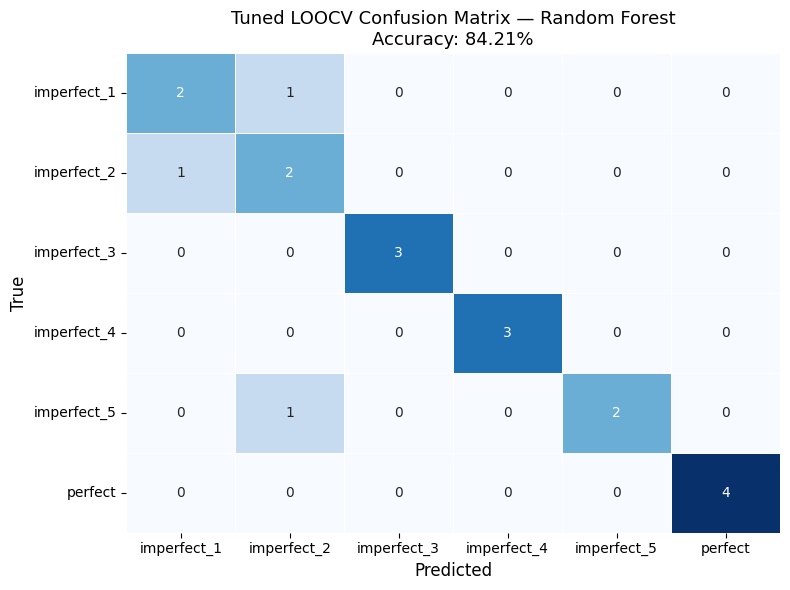


Test case: Imperfect_no_4_1_train_middle_track_2000N
  Predicted: perfect
  Actual:    imperfect_4
  Correct:   False

Class probabilities:
  imperfect_1     0.049 █
  imperfect_2     0.212 ████████
  imperfect_3     0.003 
  imperfect_4     0.211 ████████
  imperfect_5     0.050 ██
  perfect         0.476 ███████████████████


In [7]:
# Re-run LOOCV with best parameters and evaluate
best_rf_params = {"n_estimators": 200, "max_depth": None, 
                  "min_samples_split": 3, "max_features": "sqrt"}

loo = LeaveOneOut()
y_true_all = []
y_pred_all = []
folder_names_all = []

for train_idx, test_idx in loo.split(X_train_raw):
    X_fold_train = X_train_raw[train_idx]
    X_fold_test = X_train_raw[test_idx]
    y_fold_train = y_train[train_idx]
    y_fold_test = y_train[test_idx]
    
    scaler = StandardScaler()
    X_fold_train_scaled = scaler.fit_transform(X_fold_train)
    X_fold_test_scaled = scaler.transform(X_fold_test)
    
    rf = RandomForestClassifier(**best_rf_params, random_state=42, class_weight="balanced")
    rf.fit(X_fold_train_scaled, y_fold_train)
    pred = rf.predict(X_fold_test_scaled)
    
    y_true_all.append(y_fold_test[0])
    y_pred_all.append(pred[0])
    folder_names_all.append(df_train.iloc[test_idx[0]]["folder_name"])

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

accuracy = accuracy_score(y_true_all, y_pred_all)
print(f"Tuned LOOCV Accuracy: {accuracy:.2%}")
print(f"\nMisclassified cases:")
for folder, true, pred in zip(folder_names_all, y_true_all, y_pred_all):
    if true != pred:
        print(f"  {folder}")
        print(f"    True: {le.classes_[true]}, Predicted: {le.classes_[pred]}")

# Confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax, cbar=False, linewidths=0.5)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"Tuned LOOCV Confusion Matrix — Random Forest\nAccuracy: {accuracy:.2%}", fontsize=13)
plt.tight_layout()
plt.savefig("results/07_confusion_matrix_rf_tuned.png", dpi=150, bbox_inches="tight")
plt.show()

# Test case prediction
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_raw)
X_test_scaled = scaler_final.transform(X_test_raw)

rf_final = RandomForestClassifier(**best_rf_params, random_state=42, class_weight="balanced")
rf_final.fit(X_train_scaled, y_train)

test_pred = rf_final.predict(X_test_scaled)
test_pred_label = le.classes_[test_pred[0]]
test_true_label = le.classes_[y_test[0]]

print(f"\nTest case: {test_folder}")
print(f"  Predicted: {test_pred_label}")
print(f"  Actual:    {test_true_label}")
print(f"  Correct:   {test_pred_label == test_true_label}")

test_proba = rf_final.predict_proba(X_test_scaled)[0]
print(f"\nClass probabilities:")
for label, prob in zip(le.classes_, test_proba):
    bar = "█" * int(prob * 40)
    print(f"  {label:15s} {prob:.3f} {bar}")

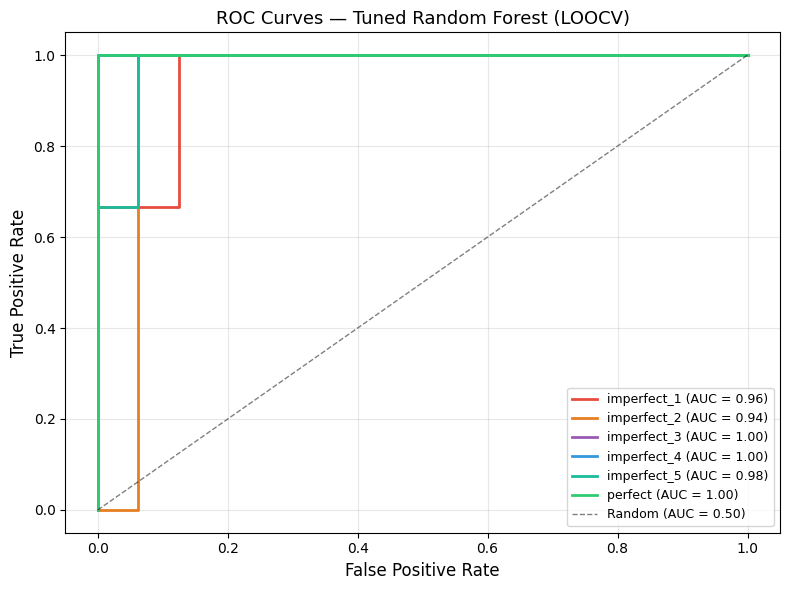

AUC scores per class:
  imperfect_1     AUC = 0.958
  imperfect_2     AUC = 0.938
  imperfect_3     AUC = 1.000
  imperfect_4     AUC = 1.000
  imperfect_5     AUC = 0.979
  perfect         AUC = 1.000

  Macro-average AUC = 0.979


In [9]:
# ROC curves and AUC scores for the tuned Random Forest
# ROC (Receiver Operating Characteristic) plots the true positive rate
# against the false positive rate at different classification thresholds.
# For multi-class problems, one curve per class is plotted using a
# one-vs-rest approach: "is this class vs everything else?"
#
# AUC (Area Under the Curve) summarises each ROC curve into a single
# number: 1.0 = perfect separation, 0.5 = random guessing.
#
# Since LOOCV produces one prediction per fold (not probabilities),
# the ROC is computed from the final model trained on all 19 samples
# using its probability estimates on the training set. This is slightly
# optimistic but acceptable given the small dataset.

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get probability predictions from LOOCV (need to re-run with probability tracking)
loo = LeaveOneOut()
y_true_loocv = []
y_proba_loocv = []

for train_idx, test_idx in loo.split(X_train_raw):
    scaler = StandardScaler()
    X_fold_train = scaler.fit_transform(X_train_raw[train_idx])
    X_fold_test = scaler.transform(X_train_raw[test_idx])
    
    rf = RandomForestClassifier(**best_rf_params, random_state=42, class_weight="balanced")
    rf.fit(X_fold_train, y_train[train_idx])
    
    y_true_loocv.append(y_train[test_idx][0])
    y_proba_loocv.append(rf.predict_proba(X_fold_test)[0])

y_true_loocv = np.array(y_true_loocv)
y_proba_loocv = np.array(y_proba_loocv)

# Binarize true labels for one-vs-rest ROC
n_classes = len(le.classes_)
y_true_bin = label_binarize(y_true_loocv, classes=list(range(n_classes)))

# Plot ROC curve for each class
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#e74c3c", "#e67e22", "#9b59b6", "#3498db", "#1abc9c", "#2ecc71"]

for i, (label, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba_loocv[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{label} (AUC = {roc_auc:.2f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC = 0.50)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Tuned Random Forest (LOOCV)", fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/08_roc_curves_rf.png", dpi=150, bbox_inches="tight")
plt.show()

# Print AUC summary
print("AUC scores per class:")
for i, label in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba_loocv[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"  {label:15s} AUC = {roc_auc:.3f}")
macro_auc = np.mean([auc(*roc_curve(y_true_bin[:, i], y_proba_loocv[:, i])[:2]) for i in range(n_classes)])
print(f"\n  Macro-average AUC = {macro_auc:.3f}")